In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = "/home/salipe/Desktop/GREAC/GREAC/output-9/benchmark_results_monkeypox.csv"
data = pd.read_csv(path)

print(f' mean = {data["final_len"].mean():.4f} std = ({data["final_len"].std():.4f})')

 mean = 54452.3200 std = (1276.8348)


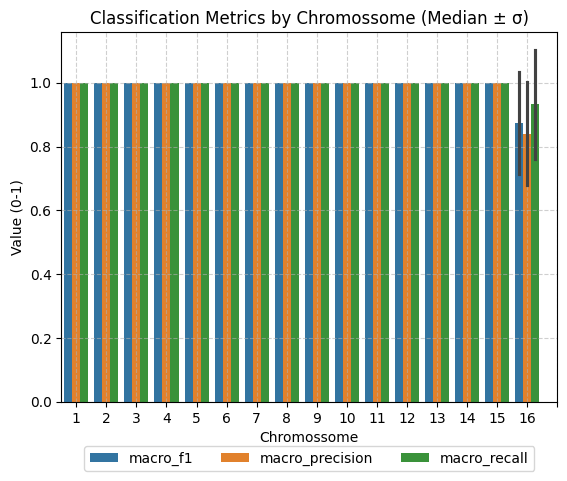

In [27]:

all_data = []

for i in range(1,17):
    sars_vars_path = f"/home/salipe/Documents/IPB/medibees/benchmarks/benchmark_results_bees{i}.csv"
    data = pd.read_csv(sars_vars_path)

    data["wndwPercent"] = data["wndwPercent"].astype("float128")

    data["chromossome"] = i  # adicionar coluna do cromossomo

    # Selecionar apenas as métricas de interesse
    subset = data[["chromossome", "macro_f1", "macro_precision", "macro_recall"]]
    all_data.append(subset)
  
    line = ""
    for metric in ["final_len","windows","kmerset","macro_f1","macro_precision","macro_recall"]:
        # print(f' {i} {metric}: mean = {data[metric].mean():.4f} std = ({data[metric].std():.4f})')
        line = f"{line} & {data[metric].mean():.2f} ({data[metric].std():.2f})"
    # print(line)
    # print('-------------------')

df_all = pd.concat(all_data, ignore_index=True)

# Transformar em formato tidy
df_melted = df_all.melt(
    id_vars="chromossome", 
    value_vars=["macro_f1", "macro_precision", "macro_recall"],
    var_name="metric", 
    value_name="value"
)

# Plot com desvio padrão como sombra
fig = plt.figure()
sns.barplot(
    data=df_melted, 
    x="chromossome", 
    y="value", 
    hue="metric", 
    errorbar="sd",   
)

plt.title("Classification Metrics by Chromossome (Median ± σ)")
plt.xlabel("Chromossome")
plt.xticks(range(0,17))
plt.ylabel("Value (0-1)")
plt.legend(
    loc="upper center",       # centraliza horizontalmente
    bbox_to_anchor=(0.5, -0.1), # posiciona acima do gráfico (ajuste o 1.08 conforme precisar)
    ncol=3                    # coloca tudo em uma linha
)
plt.grid(True, linestyle="--", alpha=0.6)


fig.savefig(f"chormossomo_lineage_metric_comparison.pdf", bbox_inches="tight")
plt.show()

In [6]:
gramep = ['AY.3',
'AY.25',
'AY.44',   
'AY.103',  
'B.1' ,
'B.1.1.7', 
'B.1.526', 
'B.1.2', 
'BA.1',  
'BA.1.1',  
'BA.1.15',  
'BA.1.18' , 
'BA.2',
'BA.2.12.2', 
'BA.4.6' ,
'BA.5.1' ,
'BA.5.2',
'BA.5.2.1' ,
'BA.5.5', 
'BQ.1.1' ]

kevolve=['B.1.1.7',
         'B.1.351',
         'P.1',
         'B.1.617.2',
         'B.1.617.1',
         'B.1.427','B.1.429',
         'B.1.526',
         'B.1.525',
         'C.37',
         'B.1.1.529',
         'BA.1.15','BA.1.18','BA.1.1','BA.2.12.1','BA.4.6','BA.5.1','BA.5.2.1','BA.5.2','BA.5.5']

In [28]:


mutations_file = '/home/salipe/Desktop/datasets/mutation_distribution_in_lineages.txt'

threshold = 0.99

mutations_df = pd.read_table(mutations_file, sep='\t', usecols=['Lineage',
                                                                    'Frequency of mutated sequences per Lineage',
                                                                    'Genome position',
                                                                    'Ref seq',
                                                                    'ut seq'])
                                                                    
mutations = mutations_df[(mutations_df['Lineage'].isin(sum([gramep],kevolve))) & (mutations_df['Frequency of mutated sequences per Lineage'] >= threshold)] 

In [30]:
mutations.to_csv("teste", index=False)

In [34]:
ls = mutations['Genome position'].to_list()
ls = list(set(ls))
ls.sort()
len(ls)


83

In [7]:
set(sum([gramep],kevolve))

{'AY.103',
 'AY.25',
 'AY.3',
 'AY.44',
 'B.1',
 'B.1.1.529',
 'B.1.1.7',
 'B.1.2',
 'B.1.351',
 'B.1.427',
 'B.1.429',
 'B.1.525',
 'B.1.526',
 'B.1.617.1',
 'B.1.617.2',
 'BA.1',
 'BA.1.1',
 'BA.1.15',
 'BA.1.18',
 'BA.2',
 'BA.2.12.1',
 'BA.2.12.2',
 'BA.4.6',
 'BA.5.1',
 'BA.5.2',
 'BA.5.2.1',
 'BA.5.5',
 'BQ.1.1',
 'C.37',
 'P.1'}

## DENV annotation file positions 

In [7]:

denv = '/home/salipe/Desktop/datasets/denv/annotation.gff3'

gff = pd.read_csv(denv, sep="\t", comment="#", header=None,
                  names=["seqid", "source", "type", "start", "end", "score", "strand", "phase", "attributes"])

# Filtra genes (ou qualquer outro tipo)
genes = gff[gff["type"].isin(["exon","CDS","mature_protein_region_of_CDS","five_prime_UTR","three_prime_UTR"])]

# Cria lista de dicionários
dados = []
tupples = []
for idx, row in genes.iterrows():
    atributos = row['attributes']
    
    # Opcional: extrai ID e Name dos atributos
    attr_dict = dict(item.split("=") for item in atributos.split(";") if "=" in item)
    
    tupples.append((row["start"],row["end"]))

    dados.append({
        "seqid": row["seqid"],
        "start": row["start"],
        "end": row["end"],
        "type": row["type"]
    })
df = pd.DataFrame(dados)
df


,seqid,start,end,type
0,NC_001477.1,1,94,five_prime_UTR
1,NC_001477.1,95,10273,CDS
2,NC_001477.1,95,436,mature_protein_region_of_CDS
3,NC_001477.1,95,394,mature_protein_region_of_CDS
4,NC_001477.1,437,934,mature_protein_region_of_CDS
5,NC_001477.1,437,709,mature_protein_region_of_CDS
6,NC_001477.1,710,934,mature_protein_region_of_CDS
7,NC_001477.1,935,2419,mature_protein_region_of_CDS
8,NC_001477.1,2420,3475,mature_protein_region_of_CDS
9,NC_001477.1,3476,4129,mature_protein_region_of_CDS
